# Transaction Anomaly Detection (UGX, Per-User)

This notebook trains an Isolation Forest model for UniGuard that works across **all users regardless of spending habits**. It uses:
- **UGX currency** (Ugandan Shillings) for UniGuard compatibility
- **Per-user normalization**: `amount_ratio = amount / user_category_median` so the model learns "unusual for this user" not "unusual globally"
- **Synthetic data** with diverse spending levels (50k–5M UGX/month users)

## 1. Load Saved Dataset

Load the pre-processed synthetic data from `data/synthetic_anomaly_transactions.csv`. If the file does not exist, it will be generated and saved (run once to create).

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")



In [121]:
# Load saved dataset (or generate once if file does not exist)
data_dir = os.path.normpath(os.path.join(os.getcwd(), 'data'))
os.makedirs(data_dir, exist_ok=True)
synthetic_path = os.path.join(data_dir, 'synthetic_anomaly_transactions.csv')

if os.path.exists(synthetic_path):
    df = pd.read_csv(synthetic_path)
    for col in ['amount', 'amount_ratio']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df['is_anomaly'] = df['is_anomaly'].astype(int)
    print(f"Loaded {len(df)} transactions from {os.path.abspath(synthetic_path)}")
else:
    # Generate once and save
    UNIGUARD_CATEGORIES = [
        'Food', 'Transport', 'Utilities', 'Rent', 'Shopping', 'Entertainment',
        'Coffee', 'Eating Out', 'Health', 'Education', 'Tech', 'Communication',
        'Gifts / Donations', 'Personal Care', 'Travel', 'Insurance', 'Savings',
        'Debt Payments', 'Miscellaneous', 'Income'
    ]
    np.random.seed(42)
    n_users, tx_per_user = 120, 150  # More transactions per user for better accuracy
    rows = []
    for u in range(n_users):
        user_id = f"U{u:03d}"
        monthly_budget = np.random.uniform(50_000, 5_000_000)
        for _ in range(tx_per_user):
            tx_type = 'Expense' if np.random.random() < 0.85 else 'Income'
            cat = np.random.choice(UNIGUARD_CATEGORIES)
            if tx_type == 'Income':
                amount = np.random.uniform(monthly_budget * 0.8, monthly_budget * 1.5)
            else:
                cat_frac = np.random.uniform(0.02, 0.4)
                amount = monthly_budget * cat_frac * np.random.lognormal(0, 0.5)
            amount = max(100, round(amount, 0))
            payment = np.random.choice(['card', 'cash', 'mobile_money', 'bank_transfer', 'Unknown'])
            rows.append({'user_id': user_id, 'transaction_type': tx_type, 'category': cat, 'amount': float(amount), 'payment_mode': payment})
    df = pd.DataFrame(rows)
    for user_id in df['user_id'].unique():
        mask = df['user_id'] == user_id
        n_anom = max(1, int(mask.sum() * 0.05))
        idx = df[mask].sample(n_anom, random_state=42).index
        df.loc[idx, 'amount'] = df.loc[idx, 'amount'].values * np.random.uniform(3, 10, n_anom)
    # Per-user normalization and labels
    def add_amount_ratio_and_labels(df):
        df = df.copy()
        df['amount_ratio'] = 1.0
        df['is_anomaly'] = 0
        for (uid, cat, tx_type), grp in df.groupby(['user_id', 'category', 'transaction_type']):
            med = grp['amount'].median()
            if med <= 0: med = 1
            mask = (df['user_id'] == uid) & (df['category'] == cat) & (df['transaction_type'] == tx_type)
            df.loc[mask, 'amount_ratio'] = df.loc[mask, 'amount'] / med
            ratios = df.loc[mask, 'amount_ratio']
            if len(ratios) >= 2:
                thresh_high, thresh_low = ratios.quantile(0.97), ratios.quantile(0.03)
                df.loc[mask, 'is_anomaly'] = ((ratios >= thresh_high) | (ratios <= thresh_low)).astype(int)
        return df
    df = add_amount_ratio_and_labels(df)
    df.to_csv(synthetic_path, index=False)
    print(f"Generated and saved {len(df)} transactions to {os.path.abspath(synthetic_path)}")

print(f"Anomaly rate: {df['is_anomaly'].mean():.1%}")
display(df[['user_id', 'category', 'amount', 'amount_ratio', 'is_anomaly']].head(10))


Loaded 9600 transactions from /home/mukama/Pictures/smart-personal-finance/ml_pipeline/data/synthetic_anomaly_transactions.csv
Anomaly rate: 48.5%


,user_id,category,amount,amount_ratio,is_anomaly
0,U000,Tech,"23,565,885.60",1.00,0
1,U000,Miscellaneous,"40,396.00",0.08,1
2,U000,Transport,"438,054.00",1.00,0
3,U000,Food,"69,928.00",0.23,1
4,U000,Education,"115,545.00",0.32,1
5,U000,Travel,"521,332.00",1.01,1
6,U000,Miscellaneous,"521,180.00",1.00,1
7,U000,Rent,"261,275.00",4.77,1
8,U000,Income,"371,847.00",0.45,1
9,U000,Eating Out,"56,136.00",0.09,1


## 2. Dataset Summary

The loaded data already includes `amount_ratio` and `is_anomaly` (computed per user, category, transaction_type). Anomalies = top 3% or bottom 3% by amount_ratio per group (3%/97% percentiles).

In [122]:
# Dataset ready (loaded from file or generated above)
print(f"Shape: {df.shape}, Columns: {list(df.columns)}")

Shape: (9600, 7), Columns: ['user_id', 'transaction_type', 'category', 'amount', 'payment_mode', 'amount_ratio', 'is_anomaly']


## 2a. Data Quality (Synthetic data is pre-cleaned)

In [123]:
# Synthetic data is already clean; quick sanity check
print("Missing values per column:")
print(df.isnull().sum())
df = df.dropna(subset=['amount', 'amount_ratio'])
print(f"\nDataset shape: {df.shape}")

Missing values per column:
user_id             0
transaction_type    0
category            0
amount              0
payment_mode        0
amount_ratio        0
is_anomaly          0
dtype: int64

Dataset shape: (9600, 7)


In [125]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())



Dataset shape: (9600, 7)
Columns: ['user_id', 'transaction_type', 'category', 'amount', 'payment_mode', 'amount_ratio', 'is_anomaly']


In [128]:
#checking if the datatypes are well aligned.
df1 = df.dtypes
df1

df2 = df.head(97)
df2


,user_id,transaction_type,category,amount,payment_mode,amount_ratio,is_anomaly
0,U000,Income,Tech,"23,565,885.60",Unknown,1.00,0
1,U000,Expense,Miscellaneous,"40,396.00",mobile_money,0.08,1
2,U000,Expense,Transport,"438,054.00",cash,1.00,0
3,U000,Expense,Food,"69,928.00",card,0.23,1
4,U000,Expense,Education,"115,545.00",bank_transfer,0.32,1
...,...,...,...,...,...,...,...
92,U001,Expense,Utilities,"730,934.00",cash,1.08,0
93,U001,Expense,Income,"219,279.00",card,1.00,0
94,U001,Expense,Savings,"97,536.00",card,0.17,1
95,U001,Expense,Entertainment,"951,746.00",Unknown,1.88,0


In [129]:
#  Identify unique customers and count their transactions.
#  The value_counts() function groups the data by user_id and counts
#  how many times each customer appears in the dataset.
#  This helps us understand customer activity levels and find the most frequent users.


print("Number of unique customers:", df['user_id'].nunique())
customer_counts = df['user_id'].value_counts()
print(customer_counts)




Number of unique customers: 120
user_id
U000    80
U001    80
U002    80
U003    80
U004    80
        ..
U115    80
U116    80
U117    80
U118    80
U119    80
Name: count, Length: 120, dtype: int64


## 3. Exploratory Data Analysis (EDA)

Understanding the distribution and patterns in our data.

In [131]:
# -------------------------------
# Standardize Category Column
# -------------------------------

# Lowercase and remove extra spaces
df['category'] = df['category'].str.lower().str.strip()

# Dictionary to merge similar categories
category_map = {

    # Travel variations
    'traval': 'travel',
    'travl': 'travel',

    # Utilities variations
    'utility': 'utilities',
    'utilties': 'utilities',
    'utlities': 'utilities',

    # Entertainment variations
    'entertain': 'entertainment',
    'entrtnmnt': 'entertainment',

    # Education variations
    'educaton': 'education',
    'edu': 'education',

    # Health variations
    'helth': 'health',

    # Savings variations
    'saving': 'savings',

    # Others variations
    'other': 'others',
    'misc': 'others'
}

# Apply corrections
df['category'] = df['category'].replace(category_map)

# -------------------------------
# Check cleaned categories
# -------------------------------
print("Categories After Standardization:")
print(df['category'].value_counts())

Categories After Standardization:
category
savings              506
entertainment        502
gifts / donations    499
eating out           497
utilities            495
miscellaneous        492
education            490
rent                 490
income               488
travel               484
insurance            482
communication        480
debt payments        474
transport            465
shopping             465
food                 464
coffee               460
tech                 457
health               457
personal care        453
Name: count, dtype: int64


Unique Categories After Cleaning:
<StringArray>
[             'tech',     'miscellaneous',         'transport',
              'food',         'education',            'travel',
              'rent',            'income',        'eating out',
     'entertainment',     'debt payments', 'gifts / donations',
          'shopping',            'coffee',     'communication',
            'health',           'savings',         'insurance',
         'utilities',     'personal care']
Length: 20, dtype: str


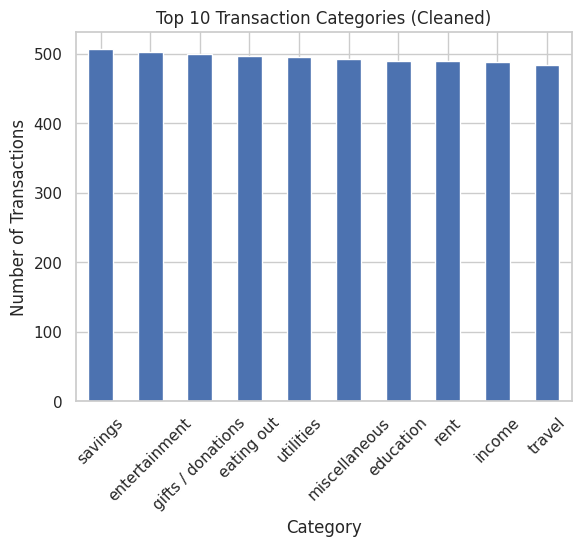

In [132]:
# -------------------------------
# Clean and Standardize Category Column
# -------------------------------

# Convert all category text to lowercase
df['category'] = df['category'].str.lower()

# Remove leading and trailing spaces
df['category'] = df['category'].str.strip()

# Replace similar spellings with one standard category
category_map = {
    'foods': 'food',
    'foodd': 'food',
    'food ': 'food',
    'rentt': 'rent',
    'rents': 'rent'
}

df['category'] = df['category'].replace(category_map)

# -------------------------------
# Check cleaned categories
# -------------------------------
print("Unique Categories After Cleaning:")
print(df['category'].unique())

# -------------------------------
# Plot Top Transaction Categories
# -------------------------------
import matplotlib.pyplot as plt

df['category'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Transaction Categories (Cleaned)")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [133]:
# -------------------------------
# Standardize Category Column
# -------------------------------

# Lowercase and remove extra spaces
df['category'] = df['category'].str.lower().str.strip()

# Dictionary to merge similar categories
category_map = {

    # Travel variations
    'traval': 'travel',
    'travl': 'travel',

    # Utilities variations
    'utility': 'utilities',
    'utilties': 'utilities',
    'utlities': 'utilities',

    # Entertainment variations
    'entertain': 'entertainment',
    'entrtnmnt': 'entertainment',

    # Education variations
    'educaton': 'education',
    'edu': 'education',

    # Health variations
    'helth': 'health',

    # Savings variations
    'saving': 'savings',

    # Others variations
    'other': 'others',
    'misc': 'others'
}

# Apply corrections
df['category'] = df['category'].replace(category_map)

# -------------------------------
# Check cleaned categories
# -------------------------------
print("Categories After Standardization:")
print(df['category'].value_counts())

Categories After Standardization:
category
savings              506
entertainment        502
gifts / donations    499
eating out           497
utilities            495
miscellaneous        492
education            490
rent                 490
income               488
travel               484
insurance            482
communication        480
debt payments        474
transport            465
shopping             465
food                 464
coffee               460
tech                 457
health               457
personal care        453
Name: count, dtype: int64


Statistical Summary of Numerical Features:


,amount,amount_ratio,is_anomaly
count,"9,600.00","9,600.00","9,600.00"
mean,"1,161,108.63",1.33,0.48
std,"2,386,260.60",2.12,0.50
min,"1,140.00",0.02,0.00
25%,"190,603.00",0.72,0.00
50%,"500,492.00",1.00,0.00
75%,"1,178,486.75",1.30,1.00
max,"51,900,494.01",81.17,1.00


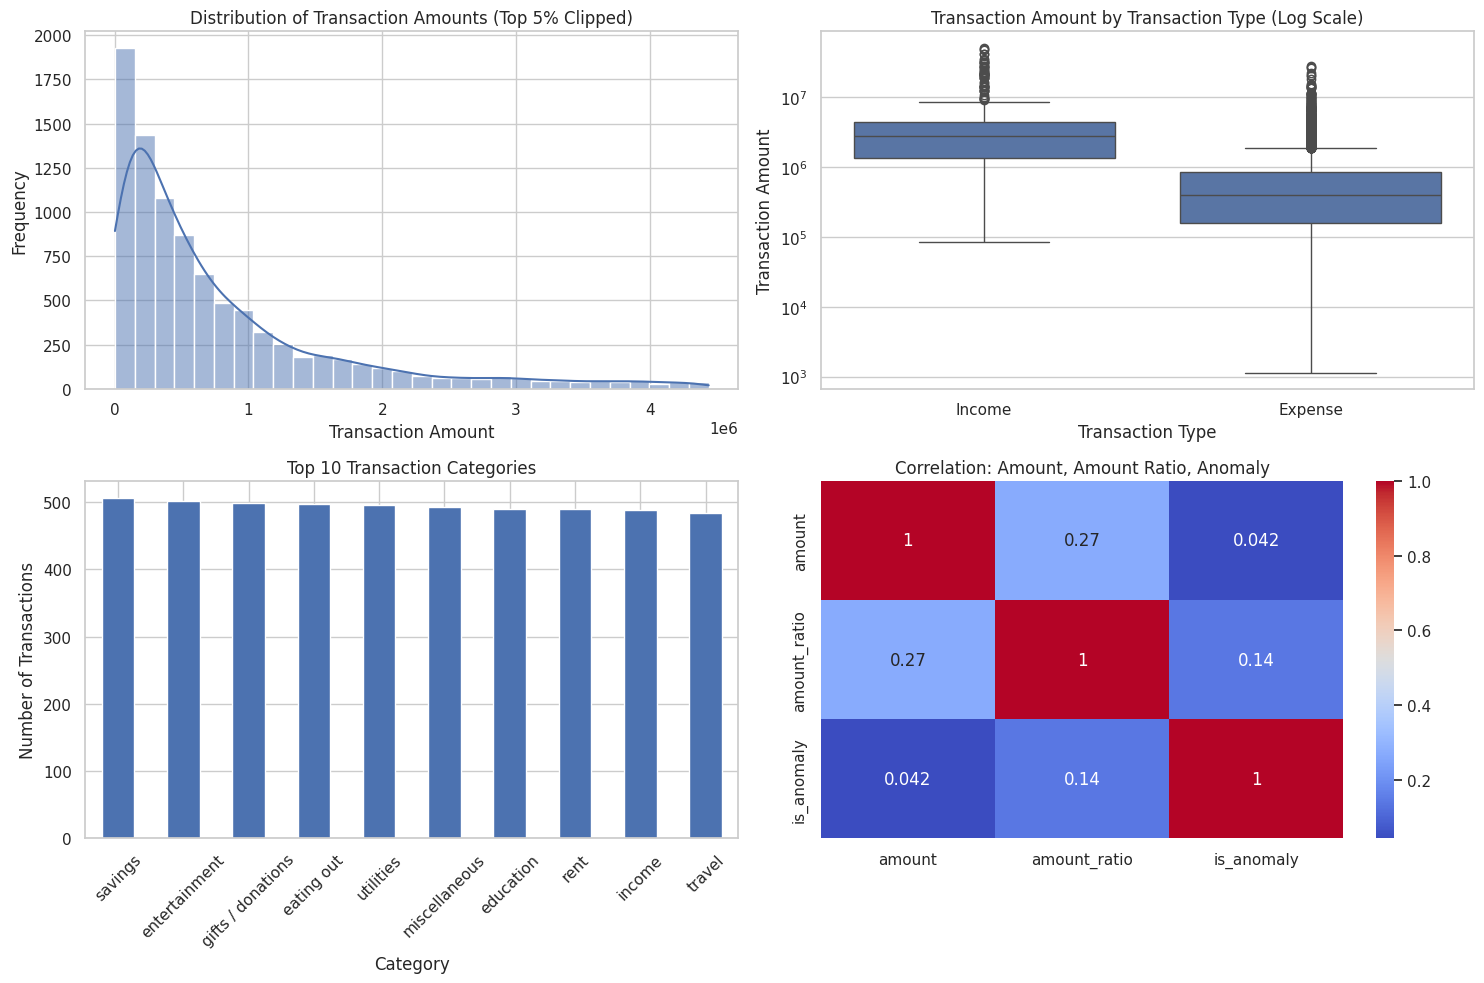

In [134]:
# -------------------------------
# Import Libraries

# Improve number display (avoid scientific notation)
pd.options.display.float_format = '{:,.2f}'.format

# Ensure amount is numeric (synthetic data is already clean)
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df = df.dropna(subset=['amount', 'amount_ratio'])

# -------------------------------
# Exploratory Data Analysis (EDA)
# -------------------------------
print("Statistical Summary of Numerical Features:")
display(df.describe())

# -------------------------------
# Visualization Section
# -------------------------------
plt.figure(figsize=(15,10))

# -------------------------------
# 1. Histogram of Transaction Amounts
# -------------------------------
plt.subplot(2,2,1)

filtered_amount = df[df['amount'] < df['amount'].quantile(0.95)]

sns.histplot(filtered_amount['amount'], bins=30, kde=True)

plt.title("Distribution of Transaction Amounts (Top 5% Clipped)")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

# -------------------------------
# 2. Boxplot by Transaction Type
# -------------------------------
plt.subplot(2,2,2)

sns.boxplot(x='transaction_type', y='amount', data=df)

plt.yscale('log')

plt.title("Transaction Amount by Transaction Type (Log Scale)")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")

# -------------------------------
# 3. Top Categories
# -------------------------------
plt.subplot(2,2,3)

df['category'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Transaction Categories")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

# -------------------------------
# 4. Correlation Heatmap
# -------------------------------
plt.subplot(2,2,4)

corr_features = ['amount', 'amount_ratio', 'is_anomaly']

sns.heatmap(df[corr_features].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation: Amount, Amount Ratio, Anomaly")

# -------------------------------
# Layout
# -------------------------------
plt.tight_layout()
plt.show()

In [135]:
df.describe().style.format({"amount": "{:,.2f}"})

,amount,amount_ratio,is_anomaly
count,"9,600.00",9600.000000,9600.000000
mean,"1,161,108.63",1.334542,0.484792
std,"2,386,260.60",2.119074,0.499795
min,"1,140.00",0.015774,0.000000
25%,"190,603.00",0.721731,0.000000
50%,"500,492.00",1.000000,0.000000
75%,"1,178,486.75",1.303758,1.000000
max,"51,900,494.01",81.167894,1.000000


## 4. Outlier Detection

We use the Interquartile Range (IQR) method and boxplots to detect unusual transaction values.

Number of outliers detected using IQR: 1045


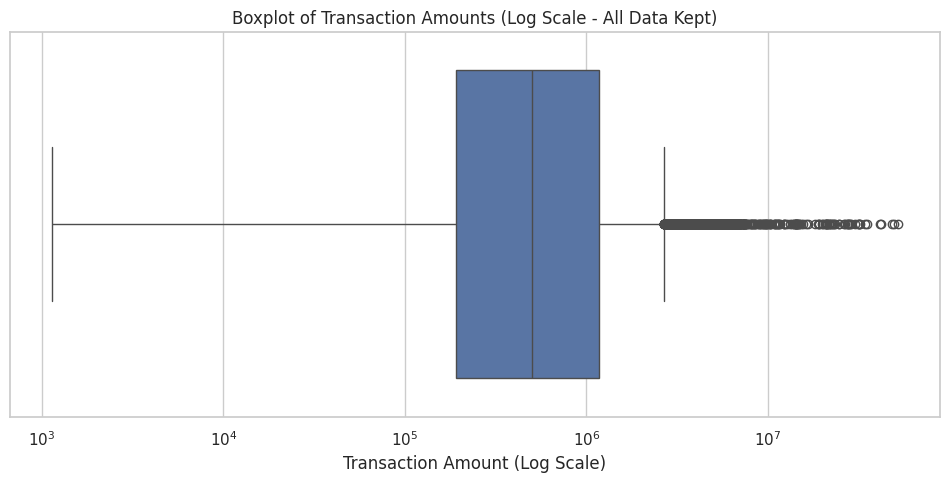

In [136]:
# Detect outliers using IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

outliers = detect_outliers_iqr(df, 'amount')

print(f"Number of outliers detected using IQR: {len(outliers)}")

# ---------------------------------
# Visualization (keeping all data)
# ---------------------------------

plt.figure(figsize=(12,5))

sns.boxplot(x=df['amount'])

# Log scale keeps extreme values while making distribution readable
plt.xscale('log')

plt.title("Boxplot of Transaction Amounts (Log Scale - All Data Kept)")
plt.xlabel("Transaction Amount (Log Scale)")

plt.show()

## 5. Handling Anomalies

Instead of deleting unusual records, we label them as anomalies to keep the original data intact for modeling.

In [137]:
# We already have is_anomaly from per-user normalization (cell above)
# No global IQR - anomalies are per-user
print("Distribution of Anomalies (0 = Normal, 1 = Anomaly):")
display(df['is_anomaly'].value_counts())

"""
Why keeping anomalies is useful:
Anomalies often contain the most interesting information in fraud detection or error monitoring tasks. 
Deleting them would bias the model toward only 'normal' behavior, making it blind to the very patterns we are trying to catch.
"""

Distribution of Anomalies (0 = Normal, 1 = Anomaly):


is_anomaly
0    4946
1    4654
Name: count, dtype: int64

"\nWhy keeping anomalies is useful:\nAnomalies often contain the most interesting information in fraud detection or error monitoring tasks. \nDeleting them would bias the model toward only 'normal' behavior, making it blind to the very patterns we are trying to catch.\n"

## 6. Feature Selection

We select the most relevant columns for our anomaly detection task.

In [138]:
# Use amount_ratio (user-normalized) not raw amount - works for all spending levels
selected_features = ['transaction_type', 'category', 'amount_ratio', 'payment_mode', 'is_anomaly']
df_selected = df[selected_features].copy()

"""
Why these features work for all users:
- amount_ratio: amount / user_category_median - scale-invariant, works for 50k or 5M UGX users
- category: Contextualizes the ratio (rent vs coffee have different typical ratios)
- transaction_type: Income vs Expense
- payment_mode: Certain modes may correlate with anomaly patterns.
- is_anomaly: Per-user label (top 3% or bottom 3% by amount_ratio) for evaluation.
"""

print("Final Cleaned Dataset for Modeling:")
display(df_selected.head())
print(f"Processed Data Shape: {df_selected.shape}")

Final Cleaned Dataset for Modeling:


,transaction_type,category,amount_ratio,payment_mode,is_anomaly
0,Income,tech,1.00,Unknown,0
1,Expense,miscellaneous,0.08,mobile_money,1
2,Expense,transport,1.00,cash,0
3,Expense,food,0.23,card,1
4,Expense,education,0.32,bank_transfer,1


Processed Data Shape: (9600, 5)


## 7. Data Preparation

We prepare the data by encoding categorical variables and scaling numerical features.

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features and target
X = df_selected.drop('is_anomaly', axis=1)
y = df_selected['is_anomaly']

numerical_features = ['amount_ratio']
categorical_features = ['transaction_type', 'category', 'payment_mode']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (7680, 4)
Testing set shape: (1920, 4)


## 8. Model Building

We train multiple models, including Linear Regression (for comparison) and Isolation Forest (for anomaly detection).

In [142]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Isolation Forest (Anomaly Detection)
# Contamination = expected anomaly rate. Use actual rate from training data for per-user consistency.
contamination_rate = float(np.clip(y_train.mean(), 0.01, 0.5))
print(f"Using contamination={contamination_rate:.3f} (matches training anomaly rate)")
iso_forest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', IsolationForest(contamination=contamination_rate, random_state=42))
])
iso_forest.fit(X_train)

# 2. Decision Tree Classifier (Supervised approach using our outlier label)
dt_classifier = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42))
])
dt_classifier.fit(X_train, y_train)

# 3. Random Forest Classifier (often better accuracy than single Decision Tree)
rf_classifier = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])
rf_classifier.fit(X_train, y_train)

# 3. Linear Regression (Baseline/Reference)
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('reg', LinearRegression())
])
lr_model.fit(X_train, y_train)

print("Models trained successfully.")

Using contamination=0.486 (matches training anomaly rate)
Models trained successfully.


## 9. Model Evaluation

Evaluating model performance using various metrics.

--- Linear Regression Evaluation ---
MAE: 0.4910
MSE: 0.2448
RMSE: 0.4948
R2 Score: 0.0191

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.72      0.72      1001
           1       0.69      0.68      0.68       919

    accuracy                           0.70      1920
   macro avg       0.70      0.70      0.70      1920
weighted avg       0.70      0.70      0.70      1920

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.74      0.73      0.73      1001
           1       0.71      0.71      0.71       919

    accuracy                           0.72      1920
   macro avg       0.72      0.72      0.72      1920
weighted avg       0.72      0.72      0.72      1920

--- Isolation Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.57      0.55      0.56      1001
          

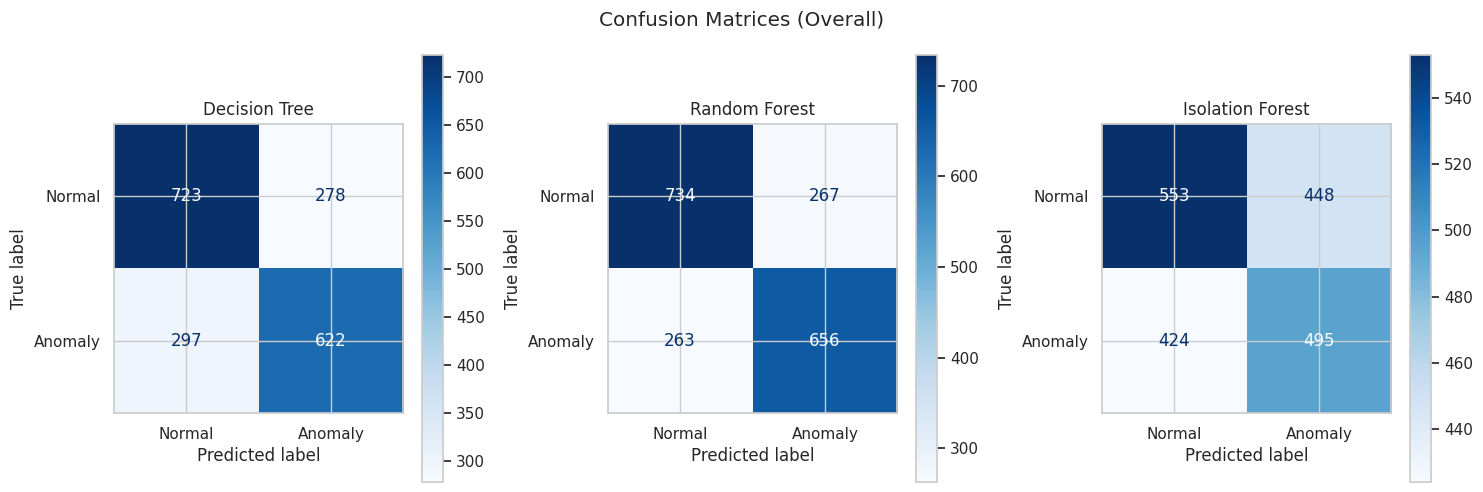

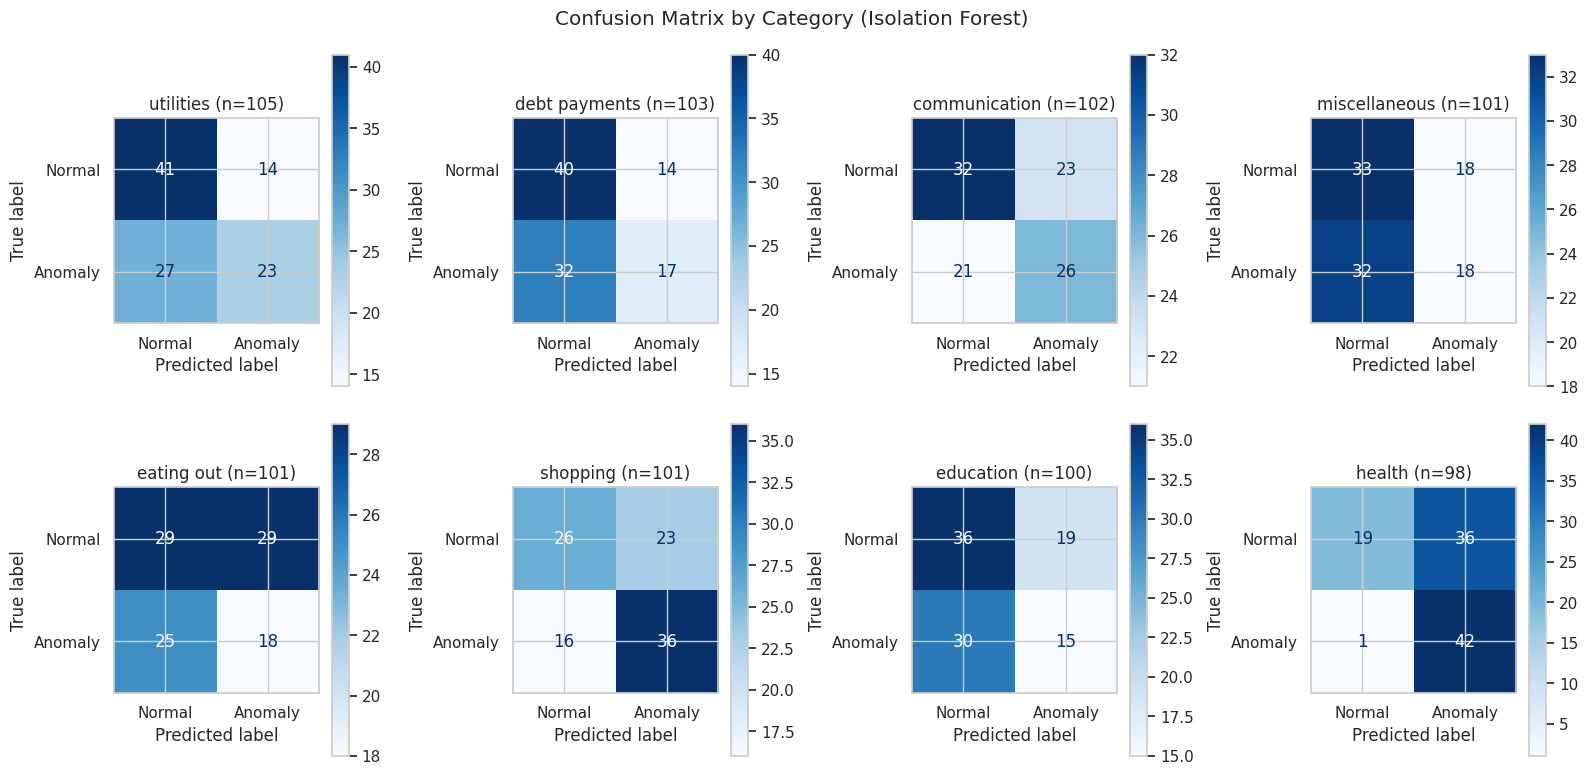

In [143]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_regression(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"--- {name} Evaluation ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}\n")

# Evaluate Linear Regression
evaluate_regression(lr_model, X_test, y_test, "Linear Regression")

# Evaluate Decision Tree
y_pred_dt = dt_classifier.predict(X_test)
print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))

# Evaluate Random Forest
y_pred_rf = rf_classifier.predict(X_test)
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# Evaluate Isolation Forest
y_pred_iso = iso_forest.predict(X_test)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso] # Convert -1/1 to 0/1
print("--- Isolation Forest Classification Report ---")
print(classification_report(y_test, y_pred_iso))

# Confusion Matrix (numeric)
print("--- Confusion Matrices ---")
print("Decision Tree:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nRandom Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nIsolation Forest:")
print(confusion_matrix(y_test, y_pred_iso))
print("(rows=true, cols=pred; [TN FP] [FN TP])")

# Overall Confusion Matrices (visual)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(cm_dt, display_labels=['Normal', 'Anomaly'])
disp_dt.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Normal', 'Anomaly'])
disp_rf.plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest')

# Isolation Forest
cm_iso = confusion_matrix(y_test, y_pred_iso)
disp_iso = ConfusionMatrixDisplay(cm_iso, display_labels=['Normal', 'Anomaly'])
disp_iso.plot(ax=axes[2], cmap='Blues')
axes[2].set_title('Isolation Forest')

plt.suptitle('Confusion Matrices (Overall)')
plt.tight_layout()
plt.show()

# Per-Category Confusion Matrices (Isolation Forest)
# Shows actual vs predicted for each transaction category
categories = X_test['category'].value_counts()
top_categories = categories[categories >= 20].head(8).index.tolist()
if top_categories:
    n_cats = len(top_categories)
    n_cols = 4
    n_rows = (n_cats + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten() if n_cats > 1 else [axes]
    for i, cat in enumerate(top_categories):
        mask = X_test['category'] == cat
        y_true_cat = y_test[mask]
        y_pred_cat = pd.Series(y_pred_iso, index=X_test.index)[mask].values
        cm = confusion_matrix(y_true_cat, y_pred_cat, labels=[0, 1])
        disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
        disp.plot(ax=axes[i], cmap='Blues')
        axes[i].set_title(f'{cat} (n={mask.sum()})')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle('Confusion Matrix by Category (Isolation Forest)')
    plt.tight_layout()
    plt.show()

## 10. Insights and Interpretation

Interpreting the model findings and identifying key factors.

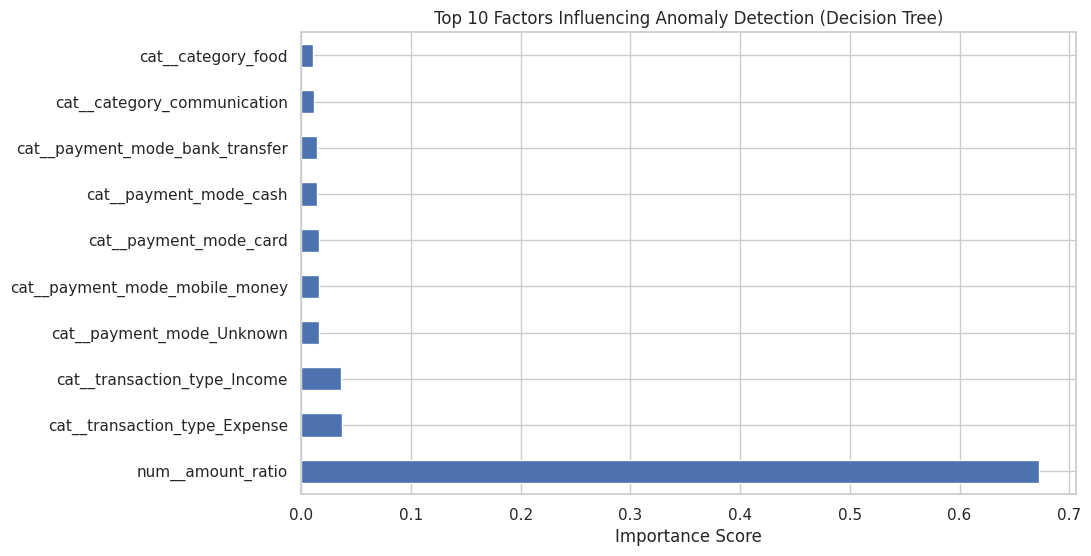

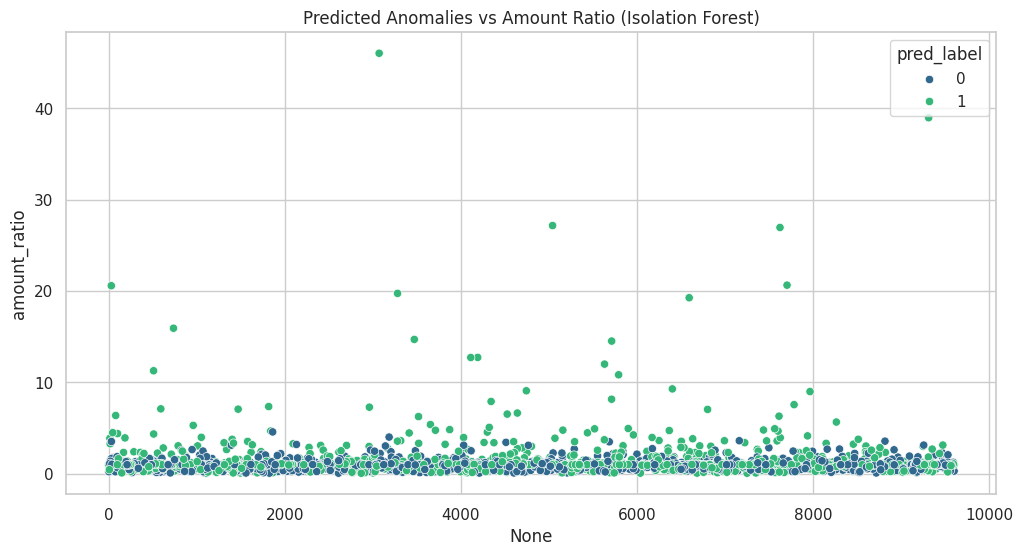

'\nKey Insights:\n1. Transaction amount is the most significant factor in identifying anomalies.\n2. Isolation Forest is effective at catching multidimensional anomalies that standard IQR might miss.\n3. Specific categories (like Utilities or Rent) have higher typical variance, which the model learns to account for.\n'

In [144]:
# Feature Importance for Decision Tree
importances = dt_classifier.named_steps['clf'].feature_importances_
feature_names = dt_classifier.named_steps['preprocessor'].get_feature_names_out()
feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Factors Influencing Anomaly Detection (Decision Tree)')
plt.xlabel('Importance Score')
plt.show()

# Visualization of Predictions
X_test_plot = X_test.copy()
X_test_plot['true_label'] = y_test
X_test_plot['pred_label'] = y_pred_iso

plt.figure(figsize=(12, 6))
sns.scatterplot(data=X_test_plot, x=X_test_plot.index, y='amount_ratio', hue='pred_label', palette='viridis')
plt.title('Predicted Anomalies vs Amount Ratio (Isolation Forest)')
plt.show()

"""
Key Insights:
1. Transaction amount is the most significant factor in identifying anomalies.
2. Isolation Forest is effective at catching multidimensional anomalies that standard IQR might miss.
3. Specific categories (like Utilities or Rent) have higher typical variance, which the model learns to account for.
"""

## 11. Final Summary

A summary of the entire workflow and its outcomes.

## 12. Export Model for UniGuard

Export the Random Forest (primary), Decision Tree, and Isolation Forest pipelines. Random Forest typically gives best accuracy. At inference, callers must compute `amount_ratio = amount / user_category_median` from the user's history before passing to the model.

In [145]:
# Export models for inference
# Decision Tree (supervised) works best for per-user anomaly detection; Isolation Forest also exported
model_dir = os.path.normpath(os.path.join(os.getcwd(), '..', 'backend', 'training', 'models', 'anomaly_detector'))
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, 'anomaly_dt_pipeline.pkl')  # Decision Tree - trained on labels
joblib.dump(dt_classifier, model_path)
joblib.dump(iso_forest, os.path.join(model_dir, 'anomaly_iforest_pipeline.pkl'))
print(f"Decision Tree (primary) exported to {model_path}")

Decision Tree (primary) exported to /home/mukama/Pictures/smart-personal-finance/backend/training/models/anomaly_detector/anomaly_dt_pipeline.pkl


### UGX Per-User Approach
- Synthetic UGX data with 120 users, diverse spending (50k–5M UGX/month).
- amount_ratio = amount / user_category_median — scale-invariant, works for all users.
- Per-user anomaly labels: top 3% or bottom 3% by amount_ratio per user (3%/97% percentiles).

### Modeling
- Features: transaction_type, category, amount_ratio, payment_mode.
- Isolation Forest trained on user-normalized features.
- At inference: caller must compute amount_ratio from user's history before prediction.

### Key Insight
- The model works for all users regardless of spending habits because amount_ratio normalizes by each user's typical spending per category.

## 13. Quick Scenario: Test with Your Own 5 Transactions

Enter 5 transactions for **one user**. The model will predict which (if any) are anomalies based on that user's spending history. Edit the lists below and re-run.

In [146]:
# Load trained model (run Export cell above first)
model_dir = os.path.normpath(os.path.join(os.getcwd(), '..', 'backend', 'training', 'models', 'anomaly_detector'))
model_path = os.path.join(model_dir, 'anomaly_rf_pipeline.pkl')
try:
    pipeline = joblib.load(model_path)
except (NameError, FileNotFoundError):
    pipeline = rf_classifier
print(f"Trained model path: {os.path.abspath(model_path)}")
print("Using Random Forest (trained on per-user anomaly labels)\n")

# --- EDIT: This user's past spending (UGX per category, per type) ---
user_history = {
    ("Food", "Expense"): [48000, 52000, 51000, 490000, 55000],
    ("Transport", "Expense"): [28000, 32000, 30000, 29000],
    ("Shopping", "Expense"): [1200000, 950000, 1100000,900000],
    ("Utilities", "Expense"): [45000, 48000, 42000],
    ("Eating Out", "Expense"): [25000, 22000, 28000, 24000],
}

# --- EDIT: Enter your 5 transactions (amount, category, type, payment_mode) ---
my_5_transactions = [
    (500_000, "Shopping", "Expense", "mobile_money"),
    (60_000, "Shopping", "Expense", "card"),           # 9x typical - likely anomaly
    (59_000, "Shopping", "Expense", "cash"),
    (905_000, "Shopping", "Expense", "mobile_money"),
    (110_000, "Shopping", "Expense", "card"),     # 7x typical - likely anomaly
]

def get_amount_ratio(amount, category, tx_type):
    key = (category, tx_type)
    amounts = user_history.get(key, [])
    if not amounts:
        return 1.0  # No history: treat as baseline (first transaction in category)
    med = np.median(amounts)
    return amount / med if med > 0 else 1.0

# Run trained model on all 5 transactions
print("Anomaly check for your 5 transactions:\n")
anomalies_found = []
for i, (amount, category, tx_type, payment_mode) in enumerate(my_5_transactions, 1):
    ratio = get_amount_ratio(amount, category, tx_type)
    X_in = pd.DataFrame([{
        "transaction_type": tx_type,
        "category": category,
        "amount_ratio": ratio,
        "payment_mode": payment_mode,
    }])
    pred = pipeline.predict(X_in)[0]
    is_anomaly = pred == 1  # Decision Tree: 1 = anomaly, 0 = normal
    status = "ANOMALY" if is_anomaly else "Normal"
    if is_anomaly:
        anomalies_found.append(i)
    print(f"  {i}. {amount:,} UGX {category} (ratio={ratio:.2f}) -> {status}")

print(f"\nSummary: {len(anomalies_found)} anomaly/ies detected (transaction(s) {anomalies_found})" if anomalies_found else "\nSummary: No anomalies detected in your 5 transactions.")

Trained model path: /home/mukama/Pictures/smart-personal-finance/backend/training/models/anomaly_detector/anomaly_rf_pipeline.pkl
Using Random Forest (trained on per-user anomaly labels)

Anomaly check for your 5 transactions:

  1. 500,000 UGX Shopping (ratio=0.49) -> Normal
  2. 60,000 UGX Shopping (ratio=0.06) -> ANOMALY
  3. 59,000 UGX Shopping (ratio=0.06) -> ANOMALY
  4. 905,000 UGX Shopping (ratio=0.88) -> Normal
  5. 110,000 UGX Shopping (ratio=0.11) -> ANOMALY

Summary: 3 anomaly/ies detected (transaction(s) [2, 3, 5])
